RED VALID POINTS: 10


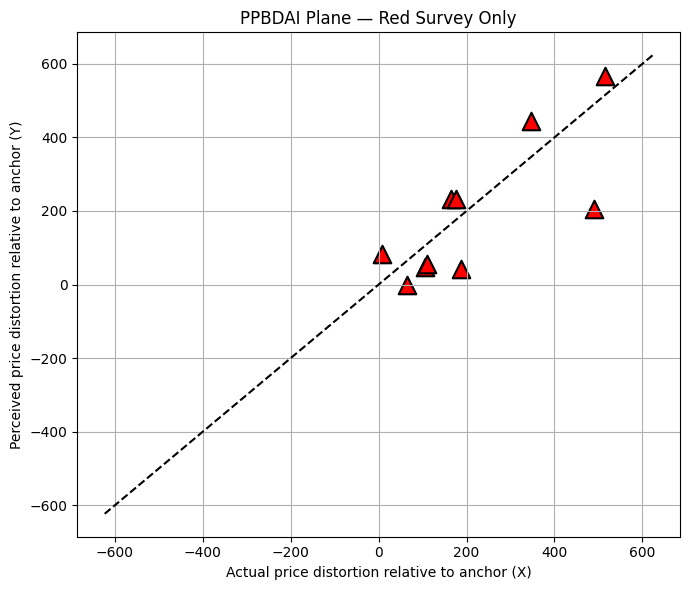

In [21]:
# ===== RED SURVEY: ROBUST LOAD + SPPAI (NO HARD-CODED COLUMN NAMES) =====

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from google.colab import files

# ---------- 1. UPLOAD ----------
files.upload()   # upload: EE red survey (Responses).xlsx

# ---------- 2. LOAD ----------
red = pd.read_excel("EE red survey (Responses).xlsx")
red["dataset"] = "Red"

# ---------- 3. ROBUST COLUMN FINDERS ----------
def find_col_contains(df, keywords):
    for c in df.columns:
        c_l = c.lower()
        if all(k in c_l for k in keywords):
            return c
    raise KeyError(f"No column found with keywords: {keywords}")

anchor_col    = find_col_contains(red, ["purchase", "price"])
perceived_col = find_col_contains(red, ["fair", "price"])
actual_col    = find_col_contains(red, ["ex", "showroom"])
income_col    = find_col_contains(red, ["income"])

# ---------- 4. MAP ----------
red["anchor_price"] = red[anchor_col]
red["actual_price"] = red[actual_col]
red["perceived_price_raw"] = red[perceived_col]
red["income_range"] = red[income_col]

# ---------- 5. PARSE PERCEIVED PRICE ----------
def parse_price(v):
    if pd.isna(v):
        return np.nan
    s = str(v).lower().replace("₹","").replace(",","").strip()
    nums = re.findall(r"\d+\.?\d*", s)
    if not nums:
        return np.nan
    val = sum(map(float, nums)) / len(nums)
    if "lakh" in s:
        val *= 100_000
    return val

red["perceived_price"] = red["perceived_price_raw"].apply(parse_price)

# ---------- 6. FORCE NUMERIC ----------
red["anchor_price"] = red["anchor_price"].astype(float)
red["actual_price"] = red["actual_price"].astype(float)

# ---------- 7. COMPUTE SPPAI ----------
red["X_actual"] = ((red["actual_price"] - red["anchor_price"]) / red["anchor_price"])*100
red["Y_perceived"] = ((red["perceived_price"] - red["anchor_price"]) / red["anchor_price"])*100

red = red.dropna(subset=["X_actual", "Y_perceived", "income_range"])

print("RED VALID POINTS:", len(red))

# ---------- 8. PLOT (RED ONLY) ----------
plt.figure(figsize=(7,6))
plt.scatter(
    red["X_actual"],
    red["Y_perceived"],
    color="red",
    marker="^",
    s=160,
    edgecolor="black",
    linewidth=1.5
)

lim = max(
    red["X_actual"].abs().max(),
    red["Y_perceived"].abs().max()
) * 1.1

plt.plot([-lim, lim], [-lim, lim], "--", color="black")
plt.xlabel("Actual price distortion relative to anchor (X)")
plt.ylabel("Perceived price distortion relative to anchor (Y)")
plt.title("PPBDAI Plane — Red Survey Only")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------- 9. EXPORT CLEAN RED ----------
red.to_excel("RED_SPPAI_CLEAN.xlsx", index=False)


In [22]:
# ===== INTERACTIVE INCOME FILTER (RED SURVEY ONLY, COLAB-SAFE) =====

import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# ---------- 1. AVAILABLE INCOME OPTIONS ----------
income_options = sorted(red["income_range"].dropna().unique())

income_selector = widgets.SelectMultiple(
    options=income_options,
    value=tuple(income_options),   # show all by default
    description="Income",
    layout=widgets.Layout(width="450px", height="220px")
)

# ---------- 2. INTERACTIVE PLOT FUNCTION ----------
def plot_red_sppai(selected_income):
    sub = red[red["income_range"].isin(selected_income)]

    if sub.empty:
        print("No data for selected income range(s).")
        return

    plt.figure(figsize=(7,6))

    plt.scatter(
        sub["X_actual"],
        sub["Y_perceived"],
        color="red",
        marker="^",
        s=160,
        edgecolor="black",
        linewidth=1.5,
        alpha=1.0
    )

    lim = max(
        sub["X_actual"].abs().max(),
        sub["Y_perceived"].abs().max()
    ) * 1.1

    plt.plot([-lim, lim], [-lim, lim], "--", color="black")

    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)

    plt.xlabel("Actual price distortion relative to anchor (X)")
    plt.ylabel("Perceived price distortion relative to anchor (Y)")
    plt.title("PPBDAI Plane — Red Survey (Income-filtered)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------- 3. DISPLAY ----------
out = widgets.interactive_output(
    plot_red_sppai,
    {"selected_income": income_selector}
)

display(income_selector, out)


SelectMultiple(description='Income', index=(0, 1, 2, 3, 4), layout=Layout(height='220px', width='450px'), opti…

Output()